In [52]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    BatchNormalization, Concatenate, Dropout,
    LeakyReLU
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

import glob
import time
import json
from datetime import datetime

In [53]:
data_path = r"E:\Based_Project\Black_&_White_Image\Data_Sets\data"
base_path = r"E:\Based_Project\Black_&_White_Image"

folders = [
    os.path.join(base_path, 'Models'),
    os.path.join(base_path, 'Results'),
    os.path.join(base_path, 'static', 'uploads'),
    os.path.join(base_path, 'static', 'css'),
    os.path.join(base_path, 'static', 'js'),
    os.path.join(base_path, 'templates')
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}")

print("\nAll folders created successfully")
print(f"Data path: {data_path}")
print(f"Base path: {base_path}")

Created: E:\Based_Project\Black_&_White_Image\Models
Created: E:\Based_Project\Black_&_White_Image\Results
Created: E:\Based_Project\Black_&_White_Image\static\uploads
Created: E:\Based_Project\Black_&_White_Image\static\css
Created: E:\Based_Project\Black_&_White_Image\static\js
Created: E:\Based_Project\Black_&_White_Image\templates

All folders created successfully
Data path: E:\Based_Project\Black_&_White_Image\Data_Sets\data
Base path: E:\Based_Project\Black_&_White_Image


### Load Dataset from data path

In [54]:
print("="*60)
print("LOADING DATASET")
print("="*60)

image_paths = []
labels = []

for cls in os.listdir(data_path):
    folder = os.path.join(data_path, cls)
    if os.path.isdir(folder):
        for img in os.listdir(folder):
            if img.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp')):
                image_paths.append(os.path.join(folder, img))
                labels.append(cls)

df = pd.DataFrame({
    'filepath': image_paths,
    'label': labels
})

print(f"Total images loaded: {len(df)}")
print(f"DataFrame shape: {df.shape}")
print("\nClass Distribution:")
print(df['label'].value_counts())
df.head()

LOADING DATASET
Total images loaded: 11478
DataFrame shape: (11478, 2)

Class Distribution:
label
train_color    5000
train_black    5000
test_color      739
test_black      739
Name: count, dtype: int64


,filepath,label
0,E:\Based_Project\Black_&_White_Image\Data_Sets...,test_black
1,E:\Based_Project\Black_&_White_Image\Data_Sets...,test_black
2,E:\Based_Project\Black_&_White_Image\Data_Sets...,test_black
3,E:\Based_Project\Black_&_White_Image\Data_Sets...,test_black
4,E:\Based_Project\Black_&_White_Image\Data_Sets...,test_black


###  Explorotary Data Anlysis

In [55]:
missing = []
for path in df['filepath']:
    if not os.path.exists(path):
        missing.append(path)
print(f"Missing Files: {len(missing)}")

corrupt = []
for path in tqdm(df['filepath'], desc='Checking Images'):
    try:
        img = cv2.imread(path)
        if img is None:
            corrupt.append(path)
    except Exception:
        corrupt.append(path)
print(f"Corrupted Images: {len(corrupt)}")

bad_images = set(missing + corrupt)
df = df[~df['filepath'].isin(bad_images)]
df = df.drop_duplicates(subset=['filepath'])
df = df.reset_index(drop=True)

print(f"Final Clean Dataset Shape: {df.shape}")
print("\nClass Distribution After Cleaning:")
print(df['label'].value_counts())

Missing Files: 0


Checking Images: 100%|██████████| 11478/11478 [01:46<00:00, 108.09it/s]

Corrupted Images: 0
Final Clean Dataset Shape: (11478, 2)

Class Distribution After Cleaning:
label
train_color    5000
train_black    5000
test_color      739
test_black      739
Name: count, dtype: int64



Dataset Information:
Total Images: 11478
Total Classes: 4
Classes: ['test_black', 'test_color', 'train_black', 'train_color']

Class Distribution:
label
train_color    5000
train_black    5000
test_color      739
test_black      739
Name: count, dtype: int64


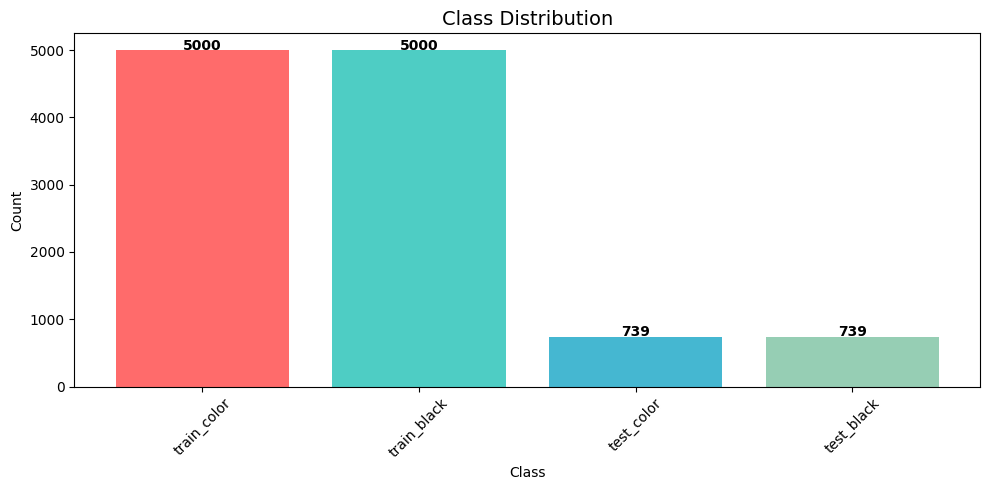


Sample Images:


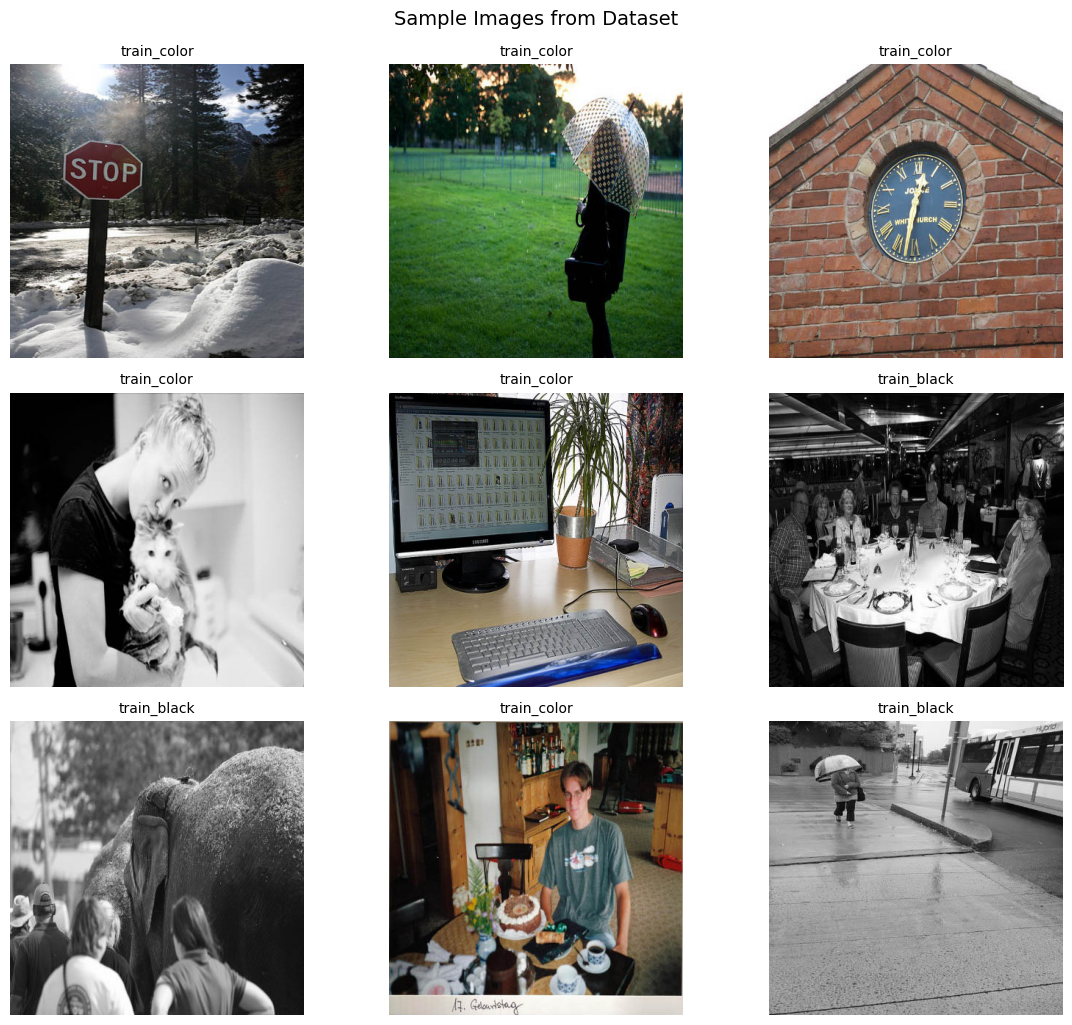

In [56]:
print("\nDataset Information:")
print(f"Total Images: {len(df)}")
print(f"Total Classes: {len(df['label'].unique())}")
print(f"Classes: {list(df['label'].unique())}")

print("\nClass Distribution:")
class_counts = df['label'].value_counts()
print(class_counts)

plt.figure(figsize=(10, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
bars = plt.bar(class_counts.index, class_counts.values, color=colors[:len(class_counts)])
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSample Images:")
sample_df = df.sample(9)
plt.figure(figsize=(12, 10))
for i, (_, row) in enumerate(sample_df.iterrows()):
    img = cv2.imread(row['filepath'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(row['label'], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.suptitle('Sample Images from Dataset', fontsize=14, y=1.02)
plt.show()

### Image loading Fuction

In [57]:
IMG_SIZE = 224

def load_image(path, img_size=224):
    img = cv2.imread(path)
    if img is None:
        return None, None
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    img_normalized = img_resized.astype(np.float32) / 255.0
    
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    gray_normalized = gray.astype(np.float32) / 255.0
    gray_normalized = np.expand_dims(gray_normalized, axis=-1)
    
    return gray_normalized, img_normalized

print("Image loading function created successfully!")

Image loading function created successfully!


### Data Generator

In [58]:
def data_generator(df, batch_size=16, img_size=224, augment=False):
    while True:
        indices = np.random.permutation(len(df))
        for i in range(0, len(df), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_gray = []
            batch_color = []
            
            for idx in batch_indices:
                row = df.iloc[idx]
                gray, color = load_image(row['filepath'], img_size)
                if gray is not None:
                    batch_gray.append(gray)
                    batch_color.append(color)
            
            if len(batch_gray) > 0:
                yield np.array(batch_gray, dtype=np.float32), np.array(batch_color, dtype=np.float32)

print("Data generator created successfully!")

Data generator created successfully!


### Train test split

In [59]:
indices = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.25,
    random_state=42,
    stratify=df['label']
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.4,
    random_state=42
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

print("\nTraining set class distribution:")
print(train_df['label'].value_counts())

print("\nValidation set class distribution:")
print(val_df['label'].value_counts())

print("\nTest set class distribution:")
print(test_df['label'].value_counts())

split_info = {
    'train_count': len(train_df),
    'val_count': len(val_df),
    'test_count': len(test_df),
    'train_classes': train_df['label'].value_counts().to_dict(),
    'val_classes': val_df['label'].value_counts().to_dict(),
    'test_classes': test_df['label'].value_counts().to_dict()
}

with open(os.path.join(base_path, 'split_info.json'), 'w') as f:
    json.dump(split_info, f, indent=4)
print(f"\nSplit info saved to: {os.path.join(base_path, 'split_info.json')}")

Training samples: 8608
Validation samples: 1722
Test samples: 1148

Training set class distribution:
label
train_color    3750
train_black    3750
test_black      554
test_color      554
Name: count, dtype: int64

Validation set class distribution:
label
train_color    749
train_black    740
test_black     122
test_color     111
Name: count, dtype: int64

Test set class distribution:
label
train_black    510
train_color    501
test_color      74
test_black      63
Name: count, dtype: int64

Split info saved to: E:\Based_Project\Black_&_White_Image\split_info.json


### Create Generators

In [60]:
BATCH_SIZE = 16

train_generator = data_generator(train_df, batch_size=BATCH_SIZE, img_size=224, augment=True)
val_generator = data_generator(val_df, batch_size=BATCH_SIZE, img_size=224, augment=False)
test_generator = data_generator(test_df, batch_size=BATCH_SIZE, img_size=224, augment=False)

steps_per_epoch = len(train_df) // BATCH_SIZE
validation_steps = len(val_df) // BATCH_SIZE
test_steps = len(test_df) // BATCH_SIZE

print(f"Training steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print(f"Test steps: {test_steps}")

Training steps per epoch: 538
Validation steps: 107
Test steps: 71


### Build U-Net + CNN Model

In [61]:
def build_unet(input_shape=(224, 224, 1)):
    inputs = Input(shape=input_shape)
    
    conv1 = Conv2D(32, (3, 3), padding='same')(inputs)
    conv1 = BatchNormalization()(conv1)
    conv1 = LeakyReLU(alpha=0.2)(conv1)
    conv1 = Conv2D(32, (3, 3), padding='same')(conv1)
    conv1 = BatchNormalization()(conv1)
    conv1 = LeakyReLU(alpha=0.2)(conv1)
    pool1 = MaxPooling2D((2, 2))(conv1)
    
    conv2 = Conv2D(64, (3, 3), padding='same')(pool1)
    conv2 = BatchNormalization()(conv2)
    conv2 = LeakyReLU(alpha=0.2)(conv2)
    conv2 = Conv2D(64, (3, 3), padding='same')(conv2)
    conv2 = BatchNormalization()(conv2)
    conv2 = LeakyReLU(alpha=0.2)(conv2)
    pool2 = MaxPooling2D((2, 2))(conv2)
    
    conv3 = Conv2D(128, (3, 3), padding='same')(pool2)
    conv3 = BatchNormalization()(conv3)
    conv3 = LeakyReLU(alpha=0.2)(conv3)
    conv3 = Conv2D(128, (3, 3), padding='same')(conv3)
    conv3 = BatchNormalization()(conv3)
    conv3 = LeakyReLU(alpha=0.2)(conv3)
    pool3 = MaxPooling2D((2, 2))(conv3)
    
    conv4 = Conv2D(256, (3, 3), padding='same')(pool3)
    conv4 = BatchNormalization()(conv4)
    conv4 = LeakyReLU(alpha=0.2)(conv4)
    conv4 = Conv2D(256, (3, 3), padding='same')(conv4)
    conv4 = BatchNormalization()(conv4)
    conv4 = LeakyReLU(alpha=0.2)(conv4)
    pool4 = MaxPooling2D((2, 2))(conv4)
    
    conv5 = Conv2D(512, (3, 3), padding='same')(pool4)
    conv5 = BatchNormalization()(conv5)
    conv5 = LeakyReLU(alpha=0.2)(conv5)
    conv5 = Conv2D(512, (3, 3), padding='same')(conv5)
    conv5 = BatchNormalization()(conv5)
    conv5 = LeakyReLU(alpha=0.2)(conv5)
    drop5 = Dropout(0.2)(conv5)
    
    up6 = UpSampling2D((2, 2))(drop5)
    up6 = Conv2D(256, (2, 2), padding='same')(up6)
    up6 = BatchNormalization()(up6)
    up6 = LeakyReLU(alpha=0.2)(up6)
    merge6 = Concatenate()([conv4, up6])
    conv6 = Conv2D(256, (3, 3), padding='same')(merge6)
    conv6 = BatchNormalization()(conv6)
    conv6 = LeakyReLU(alpha=0.2)(conv6)
    conv6 = Conv2D(256, (3, 3), padding='same')(conv6)
    conv6 = BatchNormalization()(conv6)
    conv6 = LeakyReLU(alpha=0.2)(conv6)
    
    up7 = UpSampling2D((2, 2))(conv6)
    up7 = Conv2D(128, (2, 2), padding='same')(up7)
    up7 = BatchNormalization()(up7)
    up7 = LeakyReLU(alpha=0.2)(up7)
    merge7 = Concatenate()([conv3, up7])
    conv7 = Conv2D(128, (3, 3), padding='same')(merge7)
    conv7 = BatchNormalization()(conv7)
    conv7 = LeakyReLU(alpha=0.2)(conv7)
    conv7 = Conv2D(128, (3, 3), padding='same')(conv7)
    conv7 = BatchNormalization()(conv7)
    conv7 = LeakyReLU(alpha=0.2)(conv7)
    
    up8 = UpSampling2D((2, 2))(conv7)
    up8 = Conv2D(64, (2, 2), padding='same')(up8)
    up8 = BatchNormalization()(up8)
    up8 = LeakyReLU(alpha=0.2)(up8)
    merge8 = Concatenate()([conv2, up8])
    conv8 = Conv2D(64, (3, 3), padding='same')(merge8)
    conv8 = BatchNormalization()(conv8)
    conv8 = LeakyReLU(alpha=0.2)(conv8)
    conv8 = Conv2D(64, (3, 3), padding='same')(conv8)
    conv8 = BatchNormalization()(conv8)
    conv8 = LeakyReLU(alpha=0.2)(conv8)
    
    up9 = UpSampling2D((2, 2))(conv8)
    up9 = Conv2D(32, (2, 2), padding='same')(up9)
    up9 = BatchNormalization()(up9)
    up9 = LeakyReLU(alpha=0.2)(up9)
    merge9 = Concatenate()([conv1, up9])
    conv9 = Conv2D(32, (3, 3), padding='same')(merge9)
    conv9 = BatchNormalization()(conv9)
    conv9 = LeakyReLU(alpha=0.2)(conv9)
    conv9 = Conv2D(32, (3, 3), padding='same')(conv9)
    conv9 = BatchNormalization()(conv9)
    conv9 = LeakyReLU(alpha=0.2)(conv9)
    
    outputs = Conv2D(3, (1, 1), activation='sigmoid', padding='same')(conv9)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_unet()
model.summary()

print(f"\nTotal parameters: {model.count_params():,}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 224, 224,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_22      │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 224, 224,  │      9,248 │ leaky_re_lu_22[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_23      │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 112, 112,  │          0 │ leaky_re_lu_23[0… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_24      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 112, 112,  │     36,928 │ leaky_re_lu_24[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_25      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 56, 56,    │          0 │ leaky_re_lu_25[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_27[0][0] 

 Total params: 7,773,283 (29.65 MB)

 Trainable params: 7,766,435 (29.63 MB)

 Non-trainable params: 6,848 (26.75 KB)


Total parameters: 7,773,283


### Compile Model

In [62]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)

print("Model compiled successfully")
print(f"Loss function: Mean Squared Error (MSE)")
print(f"Metrics: Mean Absolute Error (MAE)")

Model compiled successfully
Loss function: Mean Squared Error (MSE)
Metrics: Mean Absolute Error (MAE)


### Callbacks

In [63]:
model_dir = os.path.join(base_path, 'Models')
os.makedirs(model_dir, exist_ok=True)

model_save_path = os.path.join(model_dir, 'colorization_model_best.h5')
final_model_path = os.path.join(model_dir, 'colorization_model_final.h5')

callbacks = [
    ModelCheckpoint(
        filepath=model_save_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks ready")
print(f"Model save path: {model_save_path}")
print(f"Final model path: {final_model_path}")

Callbacks ready
Model save path: E:\Based_Project\Black_&_White_Image\Models\colorization_model_best.h5
Final model path: E:\Based_Project\Black_&_White_Image\Models\colorization_model_final.h5


### Train Model 

In [65]:
steps_per_epoch = len(train_df) // BATCH_SIZE
validation_steps = len(val_df) // BATCH_SIZE

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print(f"Total epochs: 15")

start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

end_time = time.time()
training_time = (end_time - start_time) / 60

print("\n" + "="*60)
print("TRAINING COMPLETED")
print("="*60)
print(f"Total training time: {training_time:.2f} minutes")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final training MAE: {history.history['mae'][-1]:.4f}")
print(f"Final validation MAE: {history.history['val_mae'][-1]:.4f}")

Steps per epoch: 538
Validation steps: 107
Total epochs: 15
Epoch 1/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0188 - mae: 0.0917
Epoch 1: val_loss improved from None to 0.01055, saving model to E:\Based_Project\Black_&_White_Image\Models\colorization_model_best.h5


538/538 ━━━━━━━━━━━━━━━━━━━━ 4418s 8s/step - loss: 0.0095 - mae: 0.0652 - val_loss: 0.0105 - val_mae: 0.0818 - learning_rate: 1.0000e-04
Epoch 2/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 52s/step - loss: 0.0054 - mae: 0.0493 
Epoch 2: val_loss improved from 0.01055 to 0.00427, saving model to E:\Based_Project\Black_&_White_Image\Models\colorization_model_best.h5


538/538 ━━━━━━━━━━━━━━━━━━━━ 28323s 53s/step - loss: 0.0053 - mae: 0.0487 - val_loss: 0.0043 - val_mae: 0.0381 - learning_rate: 1.0000e-04
Epoch 3/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0050 - mae: 0.0460
Epoch 3: val_loss improved from 0.00427 to 0.00426, saving model to E:\Based_Project\Black_&_White_Image\Models\colorization_model_best.h5


538/538 ━━━━━━━━━━━━━━━━━━━━ 4320s 8s/step - loss: 0.0049 - mae: 0.0455 - val_loss: 0.0043 - val_mae: 0.0386 - learning_rate: 1.0000e-04
Epoch 4/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0048 - mae: 0.0442
Epoch 4: val_loss improved from 0.00426 to 0.00421, saving model to E:\Based_Project\Black_&_White_Image\Models\colorization_model_best.h5


538/538 ━━━━━━━━━━━━━━━━━━━━ 4399s 8s/step - loss: 0.0047 - mae: 0.0440 - val_loss: 0.0042 - val_mae: 0.0379 - learning_rate: 1.0000e-04
Epoch 5/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0048 - mae: 0.0439
Epoch 5: val_loss did not improve from 0.00421
538/538 ━━━━━━━━━━━━━━━━━━━━ 4363s 8s/step - loss: 0.0047 - mae: 0.0436 - val_loss: 0.0045 - val_mae: 0.0394 - learning_rate: 1.0000e-04
Epoch 6/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0045 - mae: 0.0419
Epoch 6: val_loss improved from 0.00421 to 0.00421, saving model to E:\Based_Project\Black_&_White_Image\Models\colorization_model_best.h5


538/538 ━━━━━━━━━━━━━━━━━━━━ 4338s 8s/step - loss: 0.0045 - mae: 0.0420 - val_loss: 0.0042 - val_mae: 0.0381 - learning_rate: 1.0000e-04
Epoch 7/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - loss: 0.0046 - mae: 0.0415
Epoch 7: val_loss improved from 0.00421 to 0.00397, saving model to E:\Based_Project\Black_&_White_Image\Models\colorization_model_best.h5


538/538 ━━━━━━━━━━━━━━━━━━━━ 4952s 9s/step - loss: 0.0044 - mae: 0.0408 - val_loss: 0.0040 - val_mae: 0.0368 - learning_rate: 1.0000e-04
Epoch 8/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 54s/step - loss: 0.0042 - mae: 0.0396 
Epoch 8: val_loss did not improve from 0.00397
538/538 ━━━━━━━━━━━━━━━━━━━━ 29337s 55s/step - loss: 0.0043 - mae: 0.0398 - val_loss: 0.0040 - val_mae: 0.0353 - learning_rate: 1.0000e-04
Epoch 9/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0042 - mae: 0.0390
Epoch 9: val_loss improved from 0.00397 to 0.00374, saving model to E:\Based_Project\Black_&_White_Image\Models\colorization_model_best.h5


538/538 ━━━━━━━━━━━━━━━━━━━━ 4441s 8s/step - loss: 0.0042 - mae: 0.0390 - val_loss: 0.0037 - val_mae: 0.0350 - learning_rate: 1.0000e-04
Epoch 10/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0042 - mae: 0.0388
Epoch 10: val_loss did not improve from 0.00374
538/538 ━━━━━━━━━━━━━━━━━━━━ 4789s 9s/step - loss: 0.0041 - mae: 0.0381 - val_loss: 0.0041 - val_mae: 0.0358 - learning_rate: 1.0000e-04
Epoch 11/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 52s/step - loss: 0.0041 - mae: 0.0379 
Epoch 11: val_loss did not improve from 0.00374
538/538 ━━━━━━━━━━━━━━━━━━━━ 28098s 52s/step - loss: 0.0041 - mae: 0.0379 - val_loss: 0.0040 - val_mae: 0.0361 - learning_rate: 1.0000e-04
Epoch 12/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0039 - mae: 0.0372
Epoch 12: val_loss did not improve from 0.00374
538/538 ━━━━━━━━━━━━━━━━━━━━ 4457s 8s/step - loss: 0.0040 - mae: 0.0377 - val_loss: 0.0039 - val_mae: 0.0363 - learning_rate: 1.0000e-04
Epoch 13/15
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0

538/538 ━━━━━━━━━━━━━━━━━━━━ 25446s 47s/step - loss: 0.0038 - mae: 0.0357 - val_loss: 0.0037 - val_mae: 0.0339 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 15.

TRAINING COMPLETED
Total training time: 2668.95 minutes
Final training loss: 0.0038
Final validation loss: 0.0037
Final training MAE: 0.0357
Final validation MAE: 0.0339


### Save Model

In [66]:
model.save(final_model_path)
print(f"Model saved to: {final_model_path}")

print(f"Best model saved to: {model_save_path}")

# Verify saved files
print("\nVerifying saved files:")
for file in os.listdir(model_dir):
    if file.endswith('.h5'):
        size = os.path.getsize(os.path.join(model_dir, file)) / (1024 * 1024)
        print(f"  {file} - {size:.2f} MB")

print("\nModel saved successfully!")

Model saved to: E:\Based_Project\Black_&_White_Image\Models\colorization_model_final.h5
Best model saved to: E:\Based_Project\Black_&_White_Image\Models\colorization_model_best.h5

Verifying saved files:
  colorization_model_best.h5 - 89.24 MB
  colorization_model_final.h5 - 89.24 MB

Model saved successfully!


Plot Training History

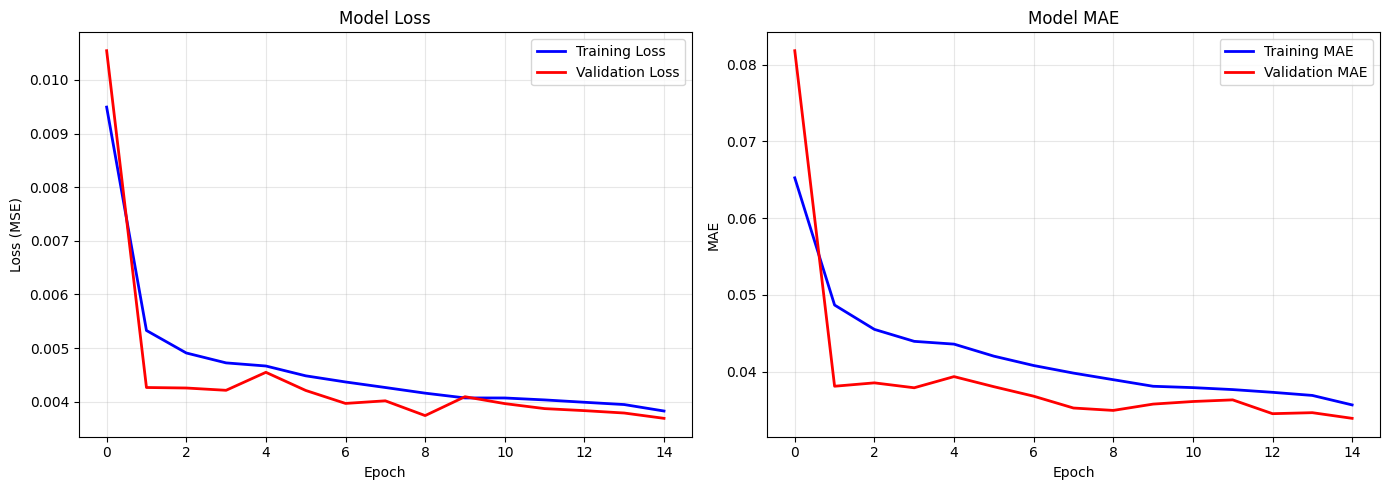

Training history plot saved to: E:\Based_Project\Black_&_White_Image\Results\training_history.png


In [67]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
plt.title('Model Loss', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', linewidth=2, color='blue')
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='red')
plt.title('Model MAE', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'Results', 'training_history.png'), dpi=150)
plt.show()
print(f"Training history plot saved to: {os.path.join(base_path, 'Results', 'training_history.png')}")

### Evaluate Model 

In [71]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np

# Use the current model instead of loading from file
# This avoids the deserialization error
best_model = model

print(f"Using current model for evaluation")

test_steps = len(test_df) // BATCH_SIZE

test_loss, test_mae = best_model.evaluate(
    test_generator,
    steps=test_steps,
    verbose=1
)

print("\n" + "="*60)
print("TEST RESULTS")
print("="*60)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Using current model for evaluation
71/71 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - loss: 0.0038 - mae: 0.0338

TEST RESULTS
Test Loss (MSE): 0.0038
Test MAE: 0.0338


In [72]:
# Ground Truth
y_true = []

val_gen = data_generator(
    val_df,
    batch_size=16,
    img_size=224,
    augment=False
)

for i in range(validation_steps):

    x_batch, y_batch = next(val_gen)

    y_true.append(y_batch)

y_true = np.concatenate(y_true, axis=0)

print(y_true.shape)

(1712, 224, 224, 3)


### Make Prediction

In [73]:
predictions = best_model.predict(
    test_generator,
    steps=test_steps,
    verbose=1
)

print(f"Predictions shape: {predictions.shape}")

# Get ground truth
y_true = []
test_gen = data_generator(test_df, batch_size=BATCH_SIZE, img_size=224, augment=False)

for i in range(test_steps):
    x_batch, y_batch = next(test_gen)
    y_true.append(y_batch)

y_true = np.concatenate(y_true, axis=0)
print(f"Ground truth shape: {y_true.shape}")

71/71 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step
Predictions shape: (1132, 224, 224, 3)
Ground truth shape: (1136, 224, 224, 3)


### Calculate Metrics

In [74]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

n = min(len(y_true), len(predictions))
y_true_new = y_true[:n]
pred_new = predictions[:n]

mse = mean_squared_error(y_true_new.reshape(-1), pred_new.reshape(-1))
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_new.reshape(-1), pred_new.reshape(-1))

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Calculate PSNR
psnr_scores = []
for i in range(min(len(y_true_new), len(pred_new))):
    try:
        score = tf.image.psnr(y_true_new[i], pred_new[i], max_val=1.0)
        psnr_scores.append(score.numpy())
    except:
        continue

if psnr_scores:
    print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB")
else:
    print("PSNR calculation failed")

# Calculate SSIM
ssim_scores = []
for i in range(min(len(y_true_new), len(pred_new))):
    try:
        score = tf.image.ssim(y_true_new[i], pred_new[i], max_val=1.0)
        ssim_scores.append(score.numpy())
    except:
        continue

if ssim_scores:
    print(f"Average SSIM: {np.mean(ssim_scores):.4f}")
else:
    print("SSIM calculation failed")

Mean Squared Error (MSE): 0.1381
Root Mean Squared Error (RMSE): 0.3717
Mean Absolute Error (MAE): 0.3017
Average PSNR: 8.93 dB
Average SSIM: 0.1471


### Visualize Results

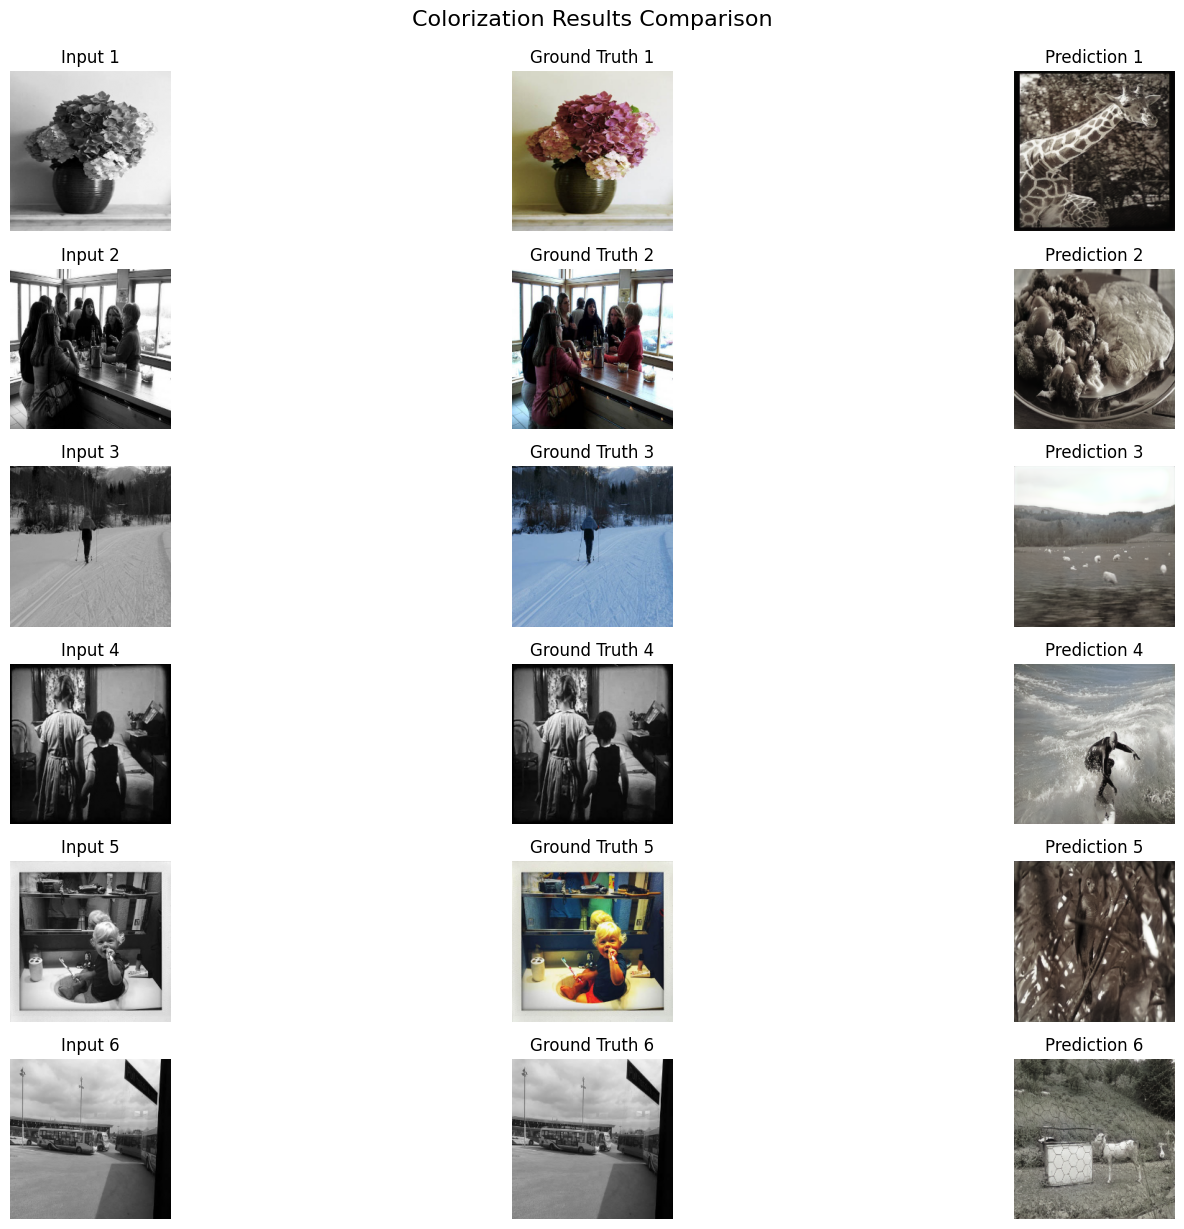

Results saved to: E:\Based_Project\Black_&_White_Image\Results\colorization_results.png


In [75]:
num_samples = min(6, len(y_true_new), len(pred_new))
plt.figure(figsize=(18, 12))

for i in range(num_samples):
    # Input (Grayscale from color image)
    plt.subplot(num_samples, 3, i * 3 + 1)
    gray_img = (y_true_new[i].mean(axis=2))
    plt.imshow(gray_img, cmap='gray')
    plt.title(f'Input {i+1}')
    plt.axis('off')
    
    # Ground Truth
    plt.subplot(num_samples, 3, i * 3 + 2)
    plt.imshow(y_true_new[i])
    plt.title(f'Ground Truth {i+1}')
    plt.axis('off')
    
    # Prediction
    plt.subplot(num_samples, 3, i * 3 + 3)
    plt.imshow(pred_new[i])
    plt.title(f'Prediction {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Colorization Results Comparison', fontsize=16, y=1.02)
results_dir = os.path.join(base_path, 'Results')
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, 'colorization_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Results saved to: {os.path.join(results_dir, 'colorization_results.png')}")

In [77]:
metrics = {
    'test_loss': float(test_loss),
    'test_mae': float(test_mae),
    'mse': float(mse),
    'rmse': float(rmse),
    'mae': float(mae)
}

if psnr_scores:
    metrics['avg_psnr'] = float(np.mean(psnr_scores))
if ssim_scores:
    metrics['avg_ssim'] = float(np.mean(ssim_scores))

metrics['training_time_minutes'] = float(training_time)
metrics['epochs'] = len(history.history['loss'])
metrics['model_parameters'] = int(model.count_params())

results_dir = os.path.join(base_path, 'Results')
os.makedirs(results_dir, exist_ok=True)

with open(os.path.join(results_dir, 'evaluation_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"Evaluation metrics saved to: {os.path.join(results_dir, 'evaluation_metrics.json')}")
 
for key, value in metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Evaluation metrics saved to: E:\Based_Project\Black_&_White_Image\Results\evaluation_metrics.json
test_loss: 0.0038
test_mae: 0.0338
mse: 0.1381
rmse: 0.3717
mae: 0.3017
avg_psnr: 8.9312
avg_ssim: 0.1471
training_time_minutes: 2668.9482
epochs: 15
model_parameters: 7773283


In [78]:
from tensorflow.keras.models import load_model

# Save with custom_objects
model.save(final_model_path, save_format='h5')
print(f"Model saved to: {final_model_path}")

# To load later, use:
try:
    loaded_model = load_model(final_model_path, compile=False)
    print("Model loaded successfully using compile=False")
    
    # Compile after loading
    loaded_model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='mse',
        metrics=['mae']
    )
    print("Model recompiled successfully")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Using the current model instead")

Model saved to: E:\Based_Project\Black_&_White_Image\Models\colorization_model_final.h5
Model loaded successfully using compile=False
Model recompiled successfully
